In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [21]:
df = pd.read_csv(r"C:\Users\azhar\OneDrive\Documents\Python class\class work\california house price.csv")

In [22]:
print(df.head(10))

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274             NaN   
4    -122.25     37.85                  52         1627           280.0   
5    -122.25     37.85                  52          919             NaN   
6    -122.25     37.84                  52         2535           489.0   
7    -122.25     37.84                  52         3104           687.0   
8    -122.26     37.84                  42         2555             NaN   
9    -122.25     37.84                  52         3549           707.0   

   population  households  median_income ocean_proximity  median_house_value  
0         322         126         8.3252        NEAR BAY              452600  
1        2401   

In [5]:
print(df.tail(10))

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
20630    -121.32     39.29                  11         2640           505.0   
20631    -121.40     39.33                  15         2655           493.0   
20632    -121.45     39.26                  15         2319           416.0   
20633    -121.53     39.19                  27         2080           412.0   
20634    -121.56     39.27                  28         2332           395.0   
20635    -121.09     39.48                  25         1665           374.0   
20636    -121.21     39.49                  18          697           150.0   
20637    -121.22     39.43                  17         2254           485.0   
20638    -121.32     39.43                  18         1860           409.0   
20639    -121.24     39.37                  16         2785           616.0   

       population  households  median_income ocean_proximity  \
20630        1257         445         3.5673          INLAND   
20

In [23]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20430 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB
None


In [24]:
print(df.describe())

          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20430.000000  20640.000000  20640.000000   20640.000000   
mean       537.895056   1425.476744    499.539680       3.870671   
std        421.403612   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        296.00000

In [25]:
print(df.isnull().sum())  # check missing values

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        210
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64


In [26]:
# Handle missing values in 'total_bedrooms' by filling with the mean
df['total_bedrooms'].fillna(df['total_bedrooms'].mean(), inplace=True)

C:\Users\azhar\AppData\Local\Temp\ipykernel_12084\102354521.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(df['total_bedrooms'].mean(), inplace=True)


In [27]:
# Define Features (X) and Target (y)
features = ['median_income', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households']
X = df[features]
y = df['median_house_value']

In [28]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.000000,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.000000,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.000000,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,537.895056,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.000000,565,259,3.8462,NEAR BAY,342200
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.000000,845,330,1.5603,INLAND,78100
20636,-121.21,39.49,18,697,150.000000,356,114,2.5568,INLAND,77100
20637,-121.22,39.43,17,2254,485.000000,1007,433,1.7000,INLAND,92300
20638,-121.32,39.43,18,1860,409.000000,741,349,1.8672,INLAND,84700


In [29]:
# Split Data and Train Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

LinearRegression()

In [30]:
# Get MLR Results
intercept = mlr_model.intercept_
coefficients = pd.Series(mlr_model.coef_, index=X.columns)
y_pred_mlr = mlr_model.predict(X_test)
r2 = r2_score(y_test, y_pred_mlr)

In [31]:
# Scatter Plot: Median Income vs. Median House Value (with Simple LR Line)
# Retrain Simple LR model to get the line parameters
X_simple = df[['median_income']]
y_simple = df['median_house_value']
simple_lr_model = LinearRegression()
simple_lr_model.fit(X_simple, y_simple)
y_pred_simple = simple_lr_model.predict(X_simple)

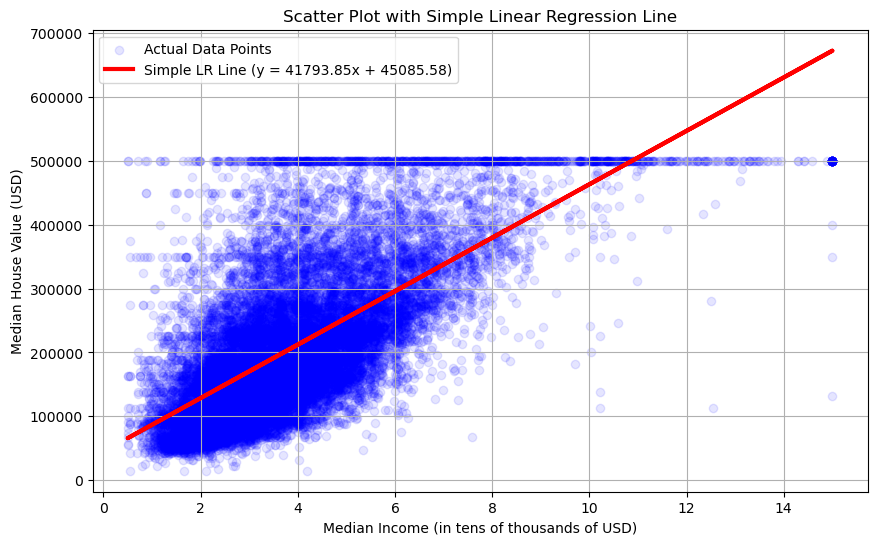

In [32]:
plt.figure(figsize=(10, 6))
plt.scatter(X_simple, y_simple, alpha=0.1, color='blue', label='Actual Data Points')
plt.plot(X_simple, y_pred_simple, color='red', linewidth=3, 
         label=f'Simple LR Line (y = {simple_lr_model.coef_[0]:.2f}x + {simple_lr_model.intercept_:.2f})')
plt.title('Scatter Plot with Simple Linear Regression Line')
plt.xlabel('Median Income (in tens of thousands of USD)')
plt.ylabel('Median House Value (USD)')
plt.legend()
plt.grid(True)
plt.savefig('scatter_and_lr_line.png') 

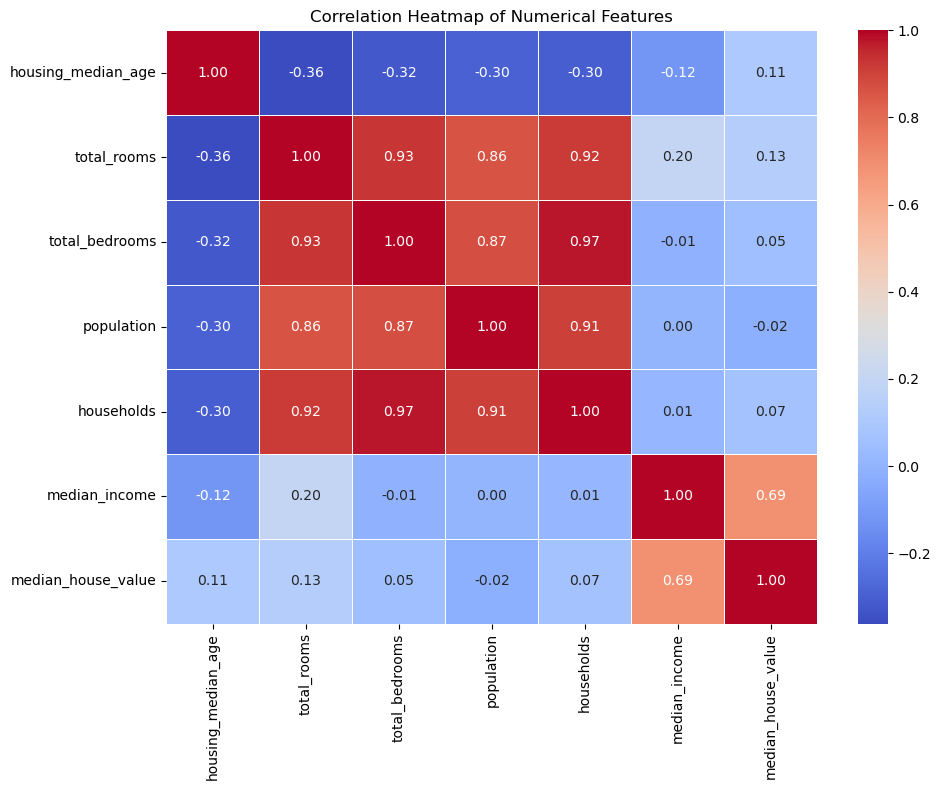

In [33]:
# Correlation Heatmap
numerical_cols = ['housing_median_age', 'total_rooms', 'total_bedrooms', 
                  'population', 'households', 'median_income', 'median_house_value']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig('correlation_heatmap_combined.png') 